# Fraud Detection: A Rules + ML Hybrid

**Author:** Aman Bohra · Senior Analytics & BI Professional
**Portfolio:** https://amandbohra.github.io/portfolio/

In the real world, fraud detection is rarely *just* a model. It's **business rules** (known red flags)
**plus** a machine-learning score (patterns humans miss), combined into one prioritized queue. This
notebook builds that hybrid on a **synthetic** claims dataset and measures how the combination beats
either piece alone.

> ⚠️ Synthetic data for demonstration only — no real or confidential client data.


In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import precision_score, recall_score, roc_auc_score
plt.rcParams.update({"figure.facecolor":"white","axes.grid":True,"grid.alpha":0.25})
rng = np.random.default_rng(13)


## 1. Synthetic claims with a small, realistic fraud rate (~4%)

In [2]:
N = 5000
amount = rng.gamma(3, 1500, N)
days_to_report = rng.poisson(6, N)+1
prior_claims = rng.poisson(0.5, N)
night_filing = rng.integers(0,2,N)
mismatch = rng.integers(0,2,N,dtype=int)          # doc mismatch flag
# latent fraud propensity
z = -3.2 + 0.00018*amount + 0.05*days_to_report + 0.5*prior_claims + 0.4*mismatch + 0.2*night_filing
p = 1/(1+np.exp(-z))
fraud = (rng.random(N) < p).astype(int)
df = pd.DataFrame({"amount":amount.round(0),"days_to_report":days_to_report,"prior_claims":prior_claims,
                   "night_filing":night_filing,"doc_mismatch":mismatch,"fraud":fraud})
print(f"Fraud rate: {df.fraud.mean():.2%}  ({df.fraud.sum()} of {N})")
df.head()


Fraud rate: 20.18%  (1009 of 5000)


,amount,days_to_report,prior_claims,night_filing,doc_mismatch,fraud
0,10351.0,9,1,0,1,0
1,6836.0,7,0,1,1,0
2,8176.0,11,1,1,0,0
3,10353.0,7,1,1,1,1
4,2864.0,4,0,0,1,0


## 2. Layer 1 — business rules (transparent red flags)

In [3]:
def rule_flags(d):
    r = ((d.amount > 12000).astype(int)
       + (d.days_to_report > 30).astype(int)
       + (d.prior_claims >= 3).astype(int)
       + (d.doc_mismatch == 1).astype(int))
    return r
df["rule_score"] = rule_flags(df)
rule_flag = (df["rule_score"] >= 2).astype(int)
print("Rules alone — precision: %.2f  recall: %.2f" % (
    precision_score(df.fraud, rule_flag), recall_score(df.fraud, rule_flag)))


Rules alone — precision: 0.51  recall: 0.04


## 3. Layer 2 — ML model (patterns the rules miss)

In [4]:
feat = ["amount","days_to_report","prior_claims","night_filing","doc_mismatch","rule_score"]
Xtr,Xte,ytr,yte = train_test_split(df[feat], df.fraud, test_size=0.3, random_state=2, stratify=df.fraud)
clf = RandomForestClassifier(n_estimators=200, class_weight="balanced", random_state=2).fit(Xtr,ytr)
proba = clf.predict_proba(Xte)[:,1]
print("ML alone — ROC AUC: %.3f" % roc_auc_score(yte, proba))


ML alone — ROC AUC: 0.618


## 4. Combine — hybrid risk score, then compare

In [5]:
te = Xte.copy(); te["fraud"]=yte.values; te["ml"]=proba
# normalise rule score to 0-1 and blend
te["rule_norm"] = te["rule_score"]/4.0
te["hybrid"] = 0.6*te["ml"] + 0.4*te["rule_norm"]

def prec_rec_at_topk(score, k=0.10):
    thr = te[score].quantile(1-k)
    flag = (te[score] >= thr).astype(int)
    return precision_score(te.fraud, flag), recall_score(te.fraud, flag)

rows=[]
for name in ["rule_norm","ml","hybrid"]:
    p,r = prec_rec_at_topk(name, 0.10)
    rows.append({"model":name,"precision@top10%":round(p,3),"recall@top10%":round(r,3)})
pd.DataFrame(rows)


,model,precision@top10%,recall@top10%
0,rule_norm,0.225,0.584
1,ml,0.329,0.168
2,hybrid,0.359,0.182


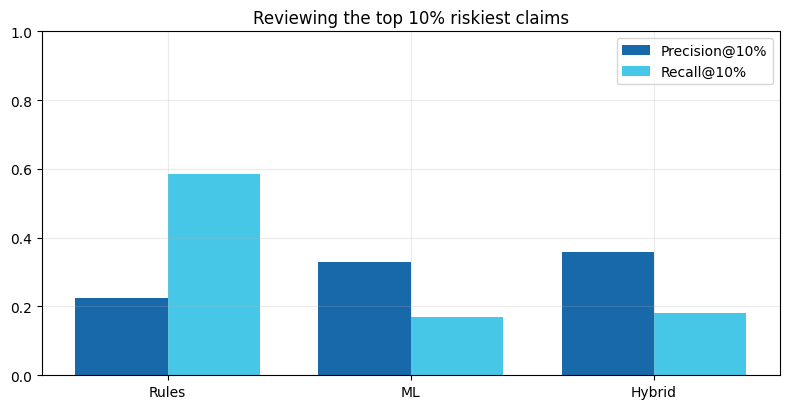

In [6]:
fig, ax = plt.subplots(figsize=(8,4.2))
labels=["Rules","ML","Hybrid"]; keys=["rule_norm","ml","hybrid"]
prec=[prec_rec_at_topk(k)[0] for k in keys]; rec=[prec_rec_at_topk(k)[1] for k in keys]
x=np.arange(3); w=0.38
ax.bar(x-w/2, prec, w, label="Precision@10%", color="#1769aa")
ax.bar(x+w/2, rec, w, label="Recall@10%", color="#46c7e8")
ax.set_xticks(x); ax.set_xticklabels(labels); ax.set_ylim(0,1)
ax.set_title("Reviewing the top 10% riskiest claims"); ax.legend()
plt.tight_layout(); plt.show()


## 5. Why hybrid wins
- **Rules** are transparent and catch known fraud patterns — but miss novel ones and over-flag.
- **ML** catches subtle patterns — but is a black box the business may not trust alone.
- **Hybrid** blends them: explainable red flags *plus* learned signal, giving a better precision/recall
  trade-off on the top-risk queue investigators actually work.

The output isn't a probability — it's a **ranked worklist** with a reason attached to each case. That's
what makes it usable, and auditable, in a regulated setting.

*— Aman Bohra*
